In [32]:
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib

  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3

In [60]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
valid_words = []

file_path = 'small.txt'

with open(file_path, 'r') as file:
    for line in file:
        sline = line.strip()
        valid_words.append(sline)

print(len(valid_words))

7690


In [19]:
def get_possible_word_scores(sample_set):
	set_count = {}
	for c in sample_set:
		if c in set_count:
			set_count[c] += 1
		else:
			set_count[c] = 1
	
	possible_word_scores = {}
	for word in valid_words:
		word_count = {}
		for c in word:
			if c in word_count:
				word_count[c] += 1
			else:
				word_count[c] = 1
		
		word_possible = True
		for w in word_count:
			if w not in set_count:
				word_possible = False
				break
			if set_count[w] < word_count[w]:
				word_possible = False
				break
		
		if not word_possible:
			continue
		
		if len(word) == 3:
			possible_word_scores[word] = 1
			continue
		
		possible_word_scores[word] = 0
		line_words = {}
		
		check_chunk(word[0]+word[1]+word[2], [0,1,2], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3], [0,1,2,3], line_words)
		check_chunk(word[1]+word[2]+word[3], [1,2,3], line_words)
		if (len(word) == 4):
			for l in line_words:
				if len(l) == 3:
					possible_word_scores[word] += 1
				else:
					possible_word_scores[word] += 2
			continue
		
		check_chunk(word[1]+word[2]+word[3]+word[4], [1,2,3,4], line_words)
		check_chunk(word[2]+word[3]+word[4], [2,3,4], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3]+word[4], [0,1,2,3,4], line_words)
		for l in line_words:
			if len(l) == 3:
				possible_word_scores[word] += 1
			elif len(l) == 4:
				possible_word_scores[word] += 2
			else:
				possible_word_scores[word] += 3
	return possible_word_scores

def check_chunk(chunk: str, indexes: [], words: {}):
	if chunk in valid_words:
		words[chunk] = indexes
	chunk = chunk[::-1]
	if chunk in valid_words:
		words[chunk] = indexes

In [246]:
def print_possible_word_total_stats(possible_word_scores):
	total = 0
	for p in possible_word_scores:
		total += possible_word_scores[p]
	return total


In [228]:
def vowel_count(letter_set):
    vowels = 0
    for l in letter_set:
        if l == 'a' or l == 'e' or l == 'i' or l == 'o' or l == 'u':
            vowels += 1
    print(f"vowels: {vowels}, consonants: {25 - vowels}")

In [229]:
from collections import OrderedDict as od
import statistics

def print_score_distribution(sample_dict):
    # Sorting using a for loop
    res = {}
    for key in sample_dict:
        if sample_dict[key] in res:
            res[sample_dict[key]] += 1
        else:
            res[sample_dict[key]] = 1

    sorted_dict = od(sorted(res.items()))
    
    print(sorted_dict)

    values = sample_dict.values()
    print(f"median: {statistics.median(values)}, mode: {statistics.mode(values)}, mean: {statistics.mean(values)}")
        
    # Create bar chart
    #plt.bar(scores, counts)
    #plt.xlim(0, 20)
    #plt.boxplot(sorted_dict, orientation='horizontal')

    
    # start the plot: 2 rows, because we want the boxplot on the first row
    # and the hist on the second
    fig, ax = plt.subplots(
        2, figsize=(7, 5), sharex=True,
        gridspec_kw={"height_ratios": (.3, .7)}  # the boxplot gets 30% of the vertical space
    )
    
    # the boxplot
    ax[0].boxplot(values, whis=[5, 95], orientation='horizontal', showfliers=False)
    
    # removing borders
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['left'].set_visible(False)

    #counts, scores = np.histogram(np.array(values))#,len(sorted_dict))
    bins = [0]
    bins.extend(sorted_dict)
    
    # the histogram
    ax[1].stairs(sorted_dict.values(), bins)
    
    # and we are good to go
    plt.show()


In [230]:
def get_all_stats(letter_set):
    scores = get_possible_word_scores(letter_set)
    print_possible_word_total_stats(scores)
    vowel_count(letter_set)
    print_score_distribution(scores)

mum's high score: 49
1351
6189
vowels: 8, consonants: 17
OrderedDict({1: 171, 2: 98, 3: 285, 4: 170, 5: 171, 6: 160, 7: 80, 8: 116, 9: 59, 10: 17, 11: 11, 12: 8, 13: 4, 14: 1})
median: 4, mode: 3, mean: 4.581051073279053


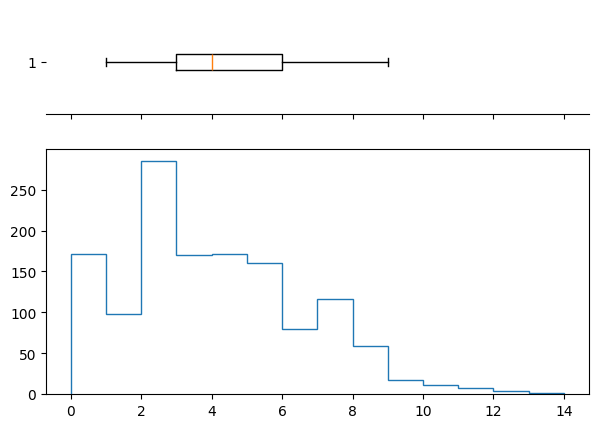

In [231]:
jun8_2026 = ["i", "s", "p", "w", "o", "r", "d", "e", "e", "b", "e", "p", "a", "l", "a", "l", "v", "e", "r", "s", "d", "p", "g", "r", "b"]
print("mum's high score: " + str(49))
get_all_stats(jun8_2026)

mum's high score: 47
1739
7881
vowels: 10, consonants: 15
OrderedDict({1: 198, 2: 149, 3: 370, 4: 240, 5: 210, 6: 232, 7: 120, 8: 94, 9: 52, 10: 39, 11: 18, 12: 4, 13: 8, 14: 2, 15: 3})
median: 4, mode: 3, mean: 4.531914893617022


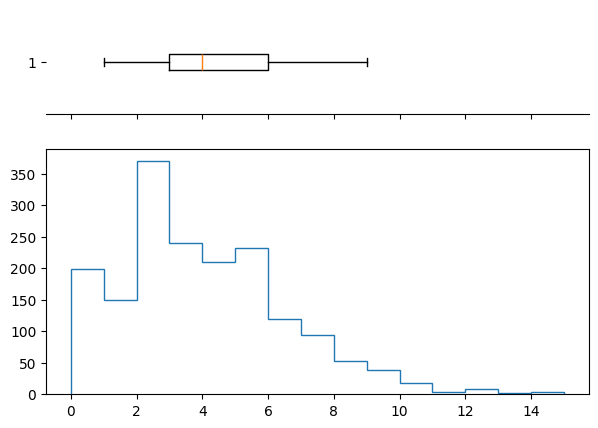

In [235]:
jun9_2026 = ["o", "c", "a", "d", "e", "o", "n", "a", "a", "d", "l", "r", "d", "t", "i", "s", "t", "r", "d", "d", "a", "t", "e", "p", "u"]
print("mum's high score: " + str(47))
get_all_stats(jun9_2026)

mum's high score: 92
800
3595
vowels: 8, consonants: 17
OrderedDict({1: 120, 2: 76, 3: 161, 4: 98, 5: 100, 6: 86, 7: 45, 8: 53, 9: 17, 10: 15, 11: 7, 12: 7, 13: 4, 15: 5, 17: 6})
median: 4.0, mode: 3, mean: 4.49375


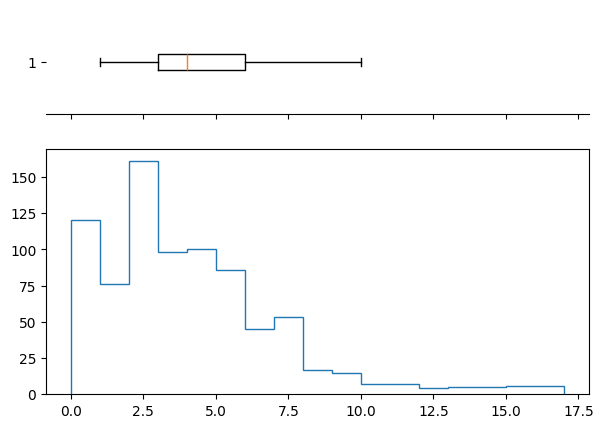

In [236]:
test_letter_set = ["s","p","a","n","s","m","n","r","a","t","a","u","i","o","o","r","n","l","p","p","t","r","a","p","s"]
print("mum's high score: " + str(92))
get_all_stats(test_letter_set)

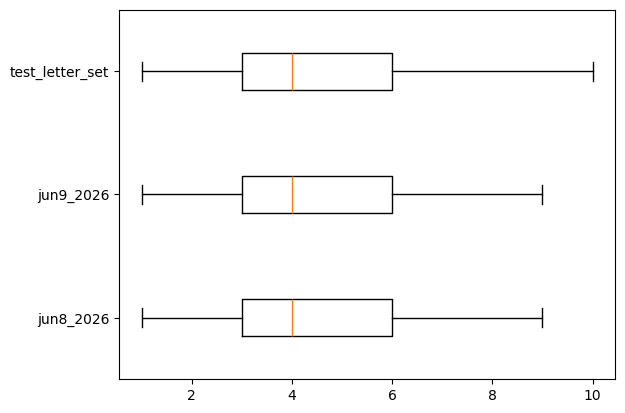

In [241]:
data = [list(get_possible_word_scores(jun8_2026).values()), list(get_possible_word_scores(jun9_2026).values()), list(get_possible_word_scores(test_letter_set).values())]

plt.boxplot(data, tick_labels=['jun8_2026', 'jun9_2026','test_letter_set'], whis=[5, 95], showfliers=False)
plt.show()


In [240]:
june = [["i", "h", "c", "m", "d", "r", "n", "m", "f", "x", "y", "l", "w", "s", "e", "n", "z", "r", "t", "r", "u", "o", "c", "a", "a"],
["s", "e", "s", "t", "t", "i", "n", "u", "e", "b", "w", "f", "r", "m", "l", "l", "y", "t", "i", "t", "o", "c", "i", "i", "w"],
["b", "u", "s", "j", "f", "s", "h", "c", "b", "l", "p", "d", "w", "e", "k", "r", "l", "b", "r", "r", "k", "t", "d", "e", "a"],
["c", "t", "l", "o", "l", "i", "s", "u", "h", "s", "c", "i", "d", "o", "i", "w", "e", "u", "b", "t", "b", "h", "g", "p", "u"],
["s", "t", "i", "e", "e", "w", "t", "y", "s", "c", "l", "y", "d", "g", "g", "i", "w", "l", "k", "w", "r", "o", "l", "d", "r"],
["e", "d", "s", "e", "s", "l", "u", "e", "b", "s", "e", "y", "j", "l", "e", "l", "b", "o", "d", "w", "i", "g", "e", "u", "b"],
["r", "l", "r", "e", "g", "s", "b", "d", "a", "b", "p", "p", "i", "e", "e", "p", "e", "v", "a", "d", "s", "l", "o", "r", "w"],
["r", "d", "n", "o", "t", "t", "e", "a", "d", "d", "p", "e", "d", "d", "o", "i", "t", "r", "a", "a", "c", "u", "s", "a", "l"],
["i", "a", "e", "s", "n", "i", "l", "a", "t", "a", "n", "a", "e", "a", "a", "l", "s", "t", "y", "e", "c", "p", "o", "d", "e"],
["o", "a", "o", "v", "r", "t", "p", "s", "t", "p", "s", "p", "e", "i", "a", "l", "a", "l", "y", "a", "n", "e", "w", "e", "e"],
["i", "l", "s", "o", "s", "p", "e", "l", "y", "s", "r", "d", "f", "l", "u", "c", "i", "s", "y", "a", "d", "o", "o", "p", "n"],
["f", "r", "v", "u", "e", "i", "e", "l", "e", "s", "b", "i", "f", "s", "s", "s", "d", "n", "l", "d", "s", "b", "w", "s", "l"],
["o", "y", "l", "e", "e", "d", "f", "c", "z", "s", "f", "t", "a", "o", "p", "k", "g", "r", "l", "o", "e", "o", "m", "a", "i"],
["a", "a", "l", "h", "c", "k", "t", "f", "a", "a", "o", "d", "s", "l", "n", "c", "w", "f", "z", "r", "s", "r", "r", "m", "c"],
["s", "o", "l", "f", "f", "s", "c", "s", "a", "d", "v", "r", "l", "l", "k", "t", "p", "s", "k", "n", "n", "a", "u", "k", "a"],
["a", "n", "r", "o", "b", "n", "b", "t", "d", "d", "h", "g", "c", "o", "g", "y", "n", "e", "p", "e", "i", "f", "l", "u", "i"],
["q", "c", "p", "a", "u", "g", "i", "p", "i", "c", "o", "s", "x", "m", "e", "n", "d", "e", "s", "a", "d", "c", "o", "u", "k"],
["a", "a", "e", "r", "g", "u", "c", "s", "a", "t", "r", "s", "y", "p", "a", "a", "s", "i", "c", "o", "e", "a", "r", "y", "w"],
["e", "e", "a", "s", "v", "a", "r", "u", "f", "i", "l", "s", "a", "b", "u", "a", "b", "a", "r", "h", "a", "e", "i", "u", "l"],
["f", "a", "c", "l", "b", "w", "m", "h", "a", "e", "m", "d", "a", "d", "p", "h", "m", "o", "u", "r", "o", "e", "p", "r", "p"],
["e", "b", "o", "o", "o", "j", "n", "a", "y", "h", "a", "m", "l", "l", "k", "h", "t", "y", "y", "s", "s", "a", "s", "e", "w"],
["o", "s", "d", "o", "s", "s", "k", "s", "s", "k", "f", "s", "r", "a", "e", "c", "i", "o", "l", "f", "a", "p", "p", "s", "e"],
["d", "l", "i", "u", "s", "m", "m", "i", "c", "s", "a", "s", "e", "h", "w", "d", "s", "r", "r", "c", "w", "r", "p", "a", "p"],
["k", "s", "f", "s", "e", "s", "f", "s", "n", "e", "a", "l", "a", "l", "r", "u", "s", "z", "o", "x", "m", "n", "u", "e", "y"],
["e", "t", "n", "w", "e", "e", "h", "t", "p", "e", "y", "t", "t", "c", "l", "e", "l", "d", "l", "o", "p", "u", "h", "b", "s"],
["p", "f", "i", "i", "e", "p", "w", "l", "t", "i", "d", "c", "d", "i", "e", "t", "a", "i", "a", "a", "t", "p", "d", "w", "i"],
["s", "g", "d", "t", "g", "t", "s", "t", "a", "d", "h", "p", "h", "t", "y", "s", "i", "u", "d", "m", "d", "l", "f", "r", "s"],
["r", "s", "o", "s", "s", "e", "m", "t", "a", "c", "r", "r", "m", "p", "l", "n", "e", "f", "u", "e", "s", "w", "f", "f", "e"]]

In [253]:
jscores = []
jlabels = []
jwords = []
jtotals = []
i = 0
for j in june:
    i += 1
    scores = get_possible_word_scores(j)
    jscores.append(list(scores.values()))
    jwords.append(len(scores))
    jtotals.append(print_possible_word_total_stats(scores))
    jlabels.append(f"jun{str(i)}_2026")


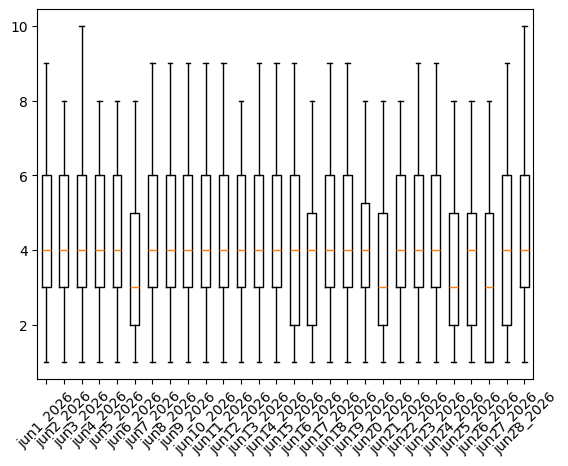

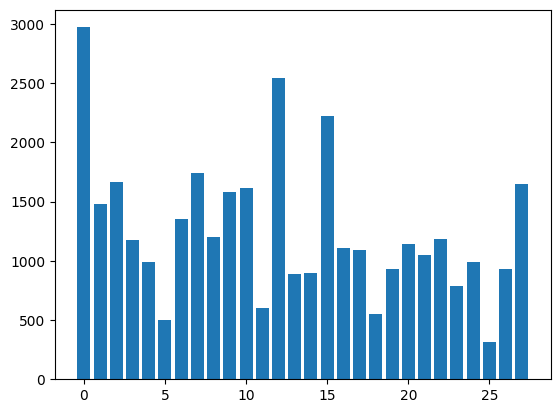

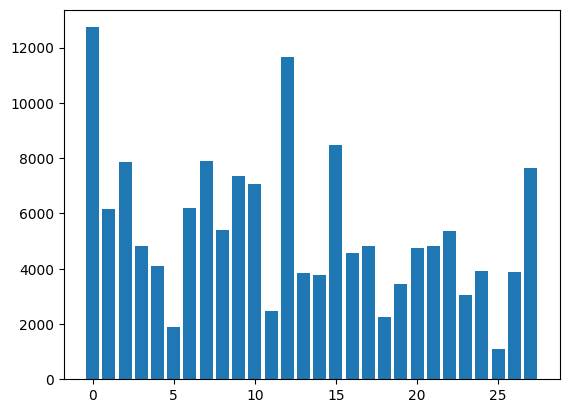

In [254]:
plt.boxplot(jscores, tick_labels=jlabels, whis=[5, 95], showfliers=False)
plt.xticks(rotation=45)
plt.show()

plt.bar(range(i), jwords)
plt.show()

plt.bar(range(i), jtotals)
plt.show()

In [255]:
june_new_gen_test = [["f", "i", "r", "s", "t", "c", "h", "i", "t", "s", "p", "u", "j", "i", "f", "u", "t", "t", "t", "o", "e", "a", "r", "h", "g"],
["b", "a", "s", "e", "s", "a", "d", "d", "e", "d", "g", "r", "i", "t", "s", "m", "i", "t", "t", "s", "r", "n", "m", "f", "x"],
["m", "o", "n", "e", "y", "t", "r", "i", "p", "s", "q", "u", "i", "c", "k", "v", "i", "z", "i", "n", "u", "e", "b", "w", "f"],
["k", "l", "u", "t", "z", "f", "i", "l", "e", "t", "t", "a", "n", "s", "y", "f", "s", "h", "c", "b", "l", "p", "d", "w", "e"],
["m", "e", "t", "r", "e", "l", "o", "l", "i", "s", "u", "h", "s", "c", "i", "d", "o", "i", "w", "e", "u", "b", "t", "b", "h"],
["r", "o", "v", "e", "d", "i", "e", "e", "w", "t", "y", "s", "c", "l", "y", "d", "g", "g", "i", "w", "l", "k", "w", "r", "o"],
["b", "l", "o", "w", "n", "b", "i", "k", "e", "s", "n", "o", "n", "n", "o", "s", "e", "d", "l", "u", "e", "b", "s", "e", "y"],
["h", "a", "r", "d", "l", "o", "n", "g", "s", "c", "u", "s", "h", "y", "g", "s", "b", "d", "a", "b", "p", "p", "i", "e", "e"],
["t", "i", "d", "e", "y", "o", "l", "k", "s", "i", "b", "i", "s", "s", "p", "o", "o", "f", "t", "e", "a", "d", "d", "p", "e"],
["g", "a", "m", "y", "a", "b", "b", "e", "r", "o", "m", "p", "s", "n", "u", "d", "e", "s", "i", "l", "a", "t", "a", "n", "a"],
["t", "r", "i", "m", "s", "b", "l", "a", "n", "d", "v", "r", "t", "p", "s", "t", "p", "s", "p", "e", "i", "a", "l", "a", "l"],
["t", "u", "r", "d", "s", "b", "o", "n", "e", "r", "s", "o", "t", "s", "s", "p", "e", "l", "y", "s", "r", "d", "f", "l", "u"],
["d", "o", "c", "k", "s", "b", "u", "c", "k", "s", "n", "a", "c", "h", "o", "e", "i", "e", "l", "e", "s", "b", "i", "f", "s"],
["v", "i", "t", "a", "l", "n", "a", "r", "c", "e", "e", "d", "f", "c", "z", "s", "f", "t", "a", "o", "p", "k", "g", "r", "l"],
["c", "u", "b", "s", "v", "u", "l", "v", "a", "u", "s", "e", "r", "s", "g", "r", "i", "n", "k", "t", "f", "a", "a", "o", "d"],
["r", "o", "a", "m", "s", "j", "e", "r", "k", "s", "h", "u", "r", "t", "f", "s", "c", "s", "a", "d", "v", "r", "l", "l", "k"],
["s", "l", "o", "e", "b", "a", "r", "f", "o", "b", "n", "b", "t", "d", "d", "h", "g", "c", "o", "g", "y", "n", "e", "p", "e"],
["r", "i", "f", "e", "r", "f", "e", "t", "i", "d", "s", "h", "o", "r", "n", "u", "g", "i", "p", "i", "c", "o", "s", "x", "m"],
["w", "h", "e", "n", "s", "n", "a", "n", "n", "y", "s", "e", "r", "e", "t", "e", "a", "s", "u", "c", "s", "a", "t", "r", "s"],
["e", "n", "d", "e", "d", "k", "i", "n", "d", "d", "o", "l", "e", "d", "c", "a", "p", "a", "r", "u", "f", "i", "l", "s", "a"],
["g", "u", "l", "l", "y", "t", "y", "r", "e", "s", "b", "e", "r", "t", "h", "b", "w", "m", "h", "a", "e", "m", "d", "a", "d"],
["b", "l", "o", "b", "t", "a", "t", "s", "c", "u", "r", "l", "y", "o", "j", "n", "a", "y", "h", "a", "m", "l", "l", "k", "h"],
["d", "r", "a", "b", "s", "p", "o", "i", "l", "o", "s", "s", "k", "s", "s", "k", "f", "s", "r", "a", "e", "c", "i", "o", "l"],
["e", "l", "f", "f", "u", "e", "l", "s", "w", "i", "z", "h", "a", "n", "k", "s", "m", "m", "i", "c", "s", "a", "s", "e", "h"],
["b", "r", "i", "s", "k", "s", "h", "a", "d", "e", "q", "u", "a", "c", "k", "e", "s", "f", "s", "n", "e", "a", "l", "a", "l"],
["c", "r", "e", "d", "o", "e", "l", "s", "e", "w", "e", "e", "h", "t", "p", "e", "y", "t", "t", "c", "l", "e", "l", "d", "l"],
["p", "a", "g", "a", "n", "i", "i", "e", "p", "w", "l", "t", "i", "d", "c", "d", "i", "e", "t", "a", "i", "a", "a", "t", "p"],
["g", "u", "n", "n", "y", "s", "a", "n", "k", "t", "g", "t", "s", "t", "a", "d", "h", "p", "h", "t", "y", "s", "i", "u", "d"],
["l", "i", "v", "e", "r", "o", "s", "s", "e", "m", "t", "a", "c", "r", "r", "m", "p", "l", "n", "e", "f", "u", "e", "s", "w"]
]

In [276]:
j2scores = []
j2labels = []
j2words = []
j2totals = []
i2 = 0
for j2 in june_new_gen_test:
    i2 += 1
    scores = get_possible_word_scores(j2)
    j2scores.append(list(scores.values()))
    j2words.append(len(scores))
    j2totals.append(print_possible_word_total_stats(scores))
    j2labels.append(f"jun{str(i2)}_new_2026")


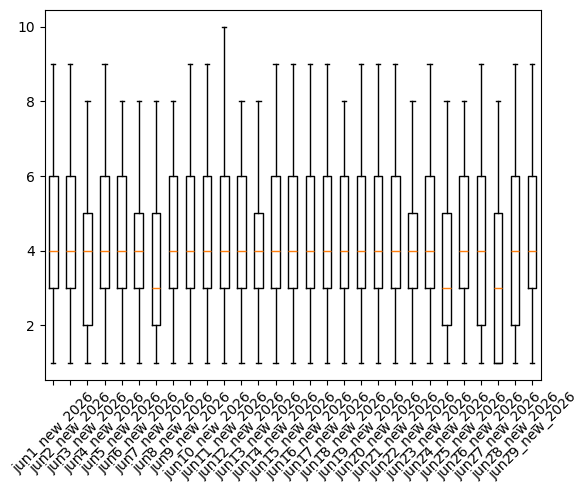

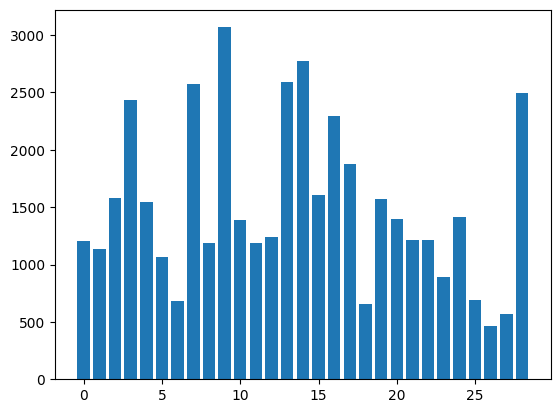

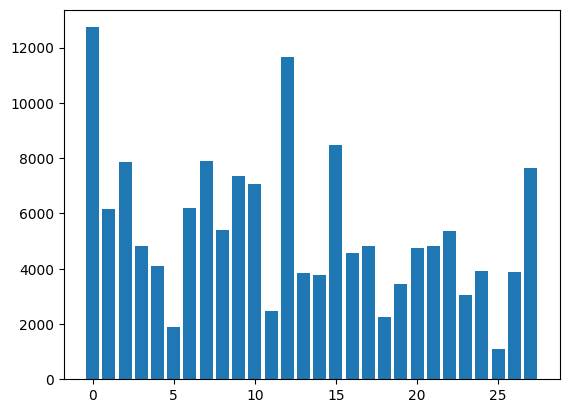

In [277]:
plt.boxplot(j2scores, tick_labels=j2labels, whis=[5, 95], showfliers=False)
plt.xticks(rotation=45)
plt.show()

plt.bar(range(i2), j2words)
plt.show()

plt.bar(range(i), jtotals)
plt.show()

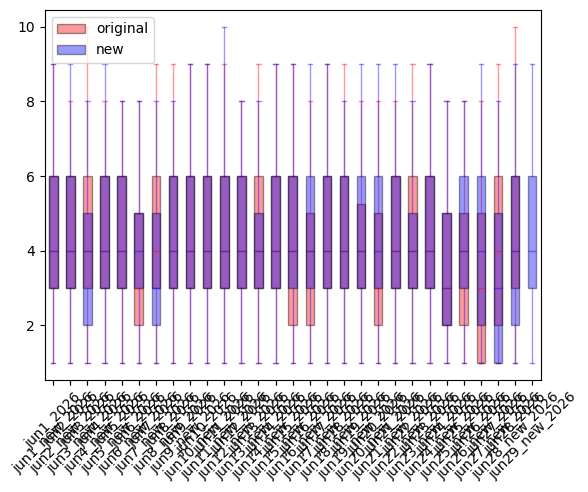

In [278]:
fig0 = plt.figure()
ax1 = fig0.add_subplot(111)

alpha = 0.4

boxplot_style = {
    'whiskerprops': {'color': 'red', 'alpha': alpha},
    'medianprops': {'color': 'red', 'alpha': alpha},
    'boxprops': {'facecolor': 'red', 'alpha': alpha},
    'capprops': {'color': 'red', 'alpha': alpha}
}


boxplot_style2 = {
    'whiskerprops': {'color': 'blue', 'alpha': alpha},
    'medianprops': {'color': 'blue', 'alpha': alpha},
    'boxprops': {'facecolor': 'blue', 'alpha': alpha},
    'capprops': {'color': 'blue', 'alpha': alpha}
    
}

ax1.boxplot(jscores, tick_labels=jlabels, whis=[5, 95], showfliers=False, label="original", patch_artist=True, **boxplot_style)
ax1.boxplot(j2scores, tick_labels=j2labels, whis=[5, 95], showfliers=False, label="new", patch_artist=True, **boxplot_style2)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.show()

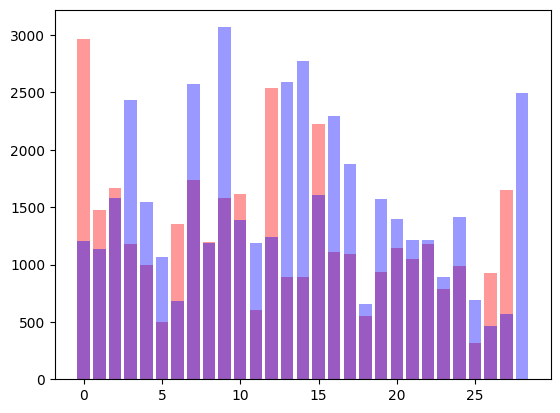

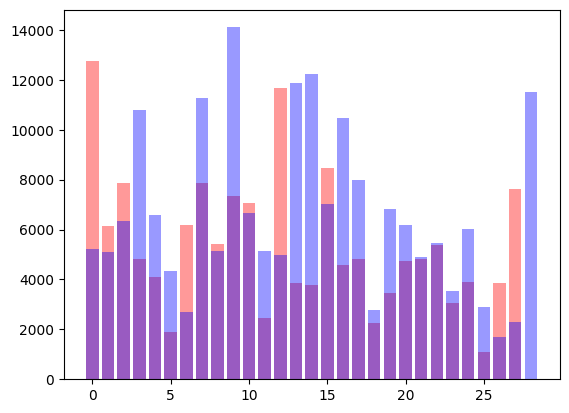

In [295]:
fig0 = plt.figure()
ax2 = fig0.add_subplot(111)

ax2.bar(range(len(jwords)), jwords, color='red', alpha=0.4)
ax2.bar(range(len(j2words)), j2words, color='blue', alpha=0.4)
plt.show()

fig1 = plt.figure()
ax3 = fig1.add_subplot(111)
ax3.bar(range(len(jtotals)), jtotals, color='red', alpha=0.4)
ax3.bar(range(len(j2totals)), j2totals, color='blue', alpha=0.4)
plt.show()